# Part 1

## Get the data


In [1]:
from sklearn.datasets import fetch_openml

# Load MNIST dataset
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

# Split the data into training and testing sets
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print("MNIST dataset loaded and split successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

MNIST dataset loaded and split successfully.
X_train shape: (60000, 784)
y_train shape: (60000,)
X_test shape: (10000, 784)
y_test shape: (10000,)


## Preprocess Data
Preprocess the MNIST image data, which typically involves normalizing pixel values.


In [2]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("X_train normalized successfully.")
print("X_test normalized successfully.")
print(f"X_train shape after normalization: {X_train.shape}")
print(f"X_test shape after normalization: {X_test.shape}")

X_train normalized successfully.
X_test normalized successfully.
X_train shape after normalization: (60000, 784)
X_test shape after normalization: (10000, 784)


## Baseline Random Forest Classifier


In [3]:
from sklearn.ensemble import RandomForestClassifier
import time

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

start_time = time.time()

print("Starting Random Forest Classifier training...")
rf_classifier.fit(X_train, y_train)
print("Random Forest Classifier training complete.")

end_time = time.time()

baseline_training_time = end_time - start_time

print(f"Baseline Random Forest Classifier training time: {baseline_training_time:.2f} seconds")

Starting Random Forest Classifier training...
Random Forest Classifier training complete.
Baseline Random Forest Classifier training time: 43.63 seconds


## Evaluate Baseline Random Forest Classifier


In [4]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred_baseline = rf_classifier.predict(X_test)

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)

conf_matrix_baseline = confusion_matrix(y_test, y_pred_baseline)

print(f"Baseline Random Forest Classifier Accuracy: {accuracy_baseline:.4f}")
print("\nBaseline Random Forest Classifier Confusion Matrix:")
print(conf_matrix_baseline)

Baseline Random Forest Classifier Accuracy: 0.9704

Baseline Random Forest Classifier Confusion Matrix:
[[ 971    0    0    0    0    2    3    1    3    0]
 [   0 1127    2    2    0    1    2    0    1    0]
 [   6    0 1002    5    3    0    3    8    5    0]
 [   1    0    9  972    0    9    0    9    8    2]
 [   1    0    0    0  955    0    5    1    4   16]
 [   5    1    1    9    2  860    5    2    5    2]
 [   7    3    0    0    3    3  937    0    5    0]
 [   1    4   20    2    0    0    0  989    2   10]
 [   4    0    6    7    5    5    5    4  930    8]
 [   7    6    2   12   12    1    0    4    4  961]]


## Apply PCA (95% variance)


In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Number of components chosen by PCA: {pca.n_components_}")
print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"X_test_pca shape: {X_test_pca.shape}")

Number of components chosen by PCA: 154
X_train_pca shape: (60000, 154)
X_test_pca shape: (10000, 154)


## Train PCA-Reduced Random Forest Classifier

In [6]:
import time

rf_classifier_pca = RandomForestClassifier(n_estimators=100, random_state=42)

start_time_pca = time.time()

print("Starting PCA-Reduced Random Forest Classifier training...")
rf_classifier_pca.fit(X_train_pca, y_train)
print("PCA-Reduced Random Forest Classifier training complete.")

end_time_pca = time.time()

pca_training_time = end_time_pca - start_time_pca

print(f"PCA-Reduced Random Forest Classifier training time: {pca_training_time:.2f} seconds")

Starting PCA-Reduced Random Forest Classifier training...
PCA-Reduced Random Forest Classifier training complete.
PCA-Reduced Random Forest Classifier training time: 131.33 seconds


In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred_pca = rf_classifier_pca.predict(X_test_pca)

accuracy_pca = accuracy_score(y_test, y_pred_pca)

conf_matrix_pca = confusion_matrix(y_test, y_pred_pca)

print(f"PCA-Reduced Random Forest Classifier Accuracy: {accuracy_pca:.4f}")
print("\nPCA-Reduced Random Forest Classifier Confusion Matrix:")
print(conf_matrix_pca)

PCA-Reduced Random Forest Classifier Accuracy: 0.9488

PCA-Reduced Random Forest Classifier Confusion Matrix:
[[ 965    0    3    1    0    3    5    2    1    0]
 [   0 1121    4    2    0    1    4    1    2    0]
 [   7    0  967   12    5    3    4   11   22    1]
 [   2    0   10  955    2   12    2    9   13    5]
 [   1    2    6    0  934    2   10    1    4   22]
 [   3    1    3   21    8  835   11    1    5    4]
 [   9    3    1    0    3    8  932    0    2    0]
 [   1    6   19    3    6    0    1  968    3   21]
 [   6    0   11   20   12   21    3    3  887   11]
 [   6    5    2   10   28    8    1   13   12  924]]


## Compare Results



In [8]:
import pandas as pd

results_data = {
    'Model': ['Baseline Random Forest', 'PCA-Reduced Random Forest'],
    'Accuracy': [accuracy_baseline, accuracy_pca],
    'Training Time (seconds)': [baseline_training_time, pca_training_time]
}

results_df = pd.DataFrame(results_data)

print("Comparison of Model Performance and Training Time:")
print(results_df)

Comparison of Model Performance and Training Time:
                       Model  Accuracy  Training Time (seconds)
0     Baseline Random Forest    0.9704                43.625517
1  PCA-Reduced Random Forest    0.9488               131.333827


The PCA-Reduced Random Forest Classifier shows a slight decrease in accuracy compared to the baseline However, it's crucial to observe the training time. The baseline model took 43.63 seconds, while the PCA-reduced model took 131.33 seconds. In this specific case, PCA increased the training time for the Random Forest Classifier, which is unexpected given its usual role in dimensionality reduction. This might be due to the nature of the dataset or the n_components=0.95 setting, which resulted in a still relatively high number of components (154).

## Visualize Comparison

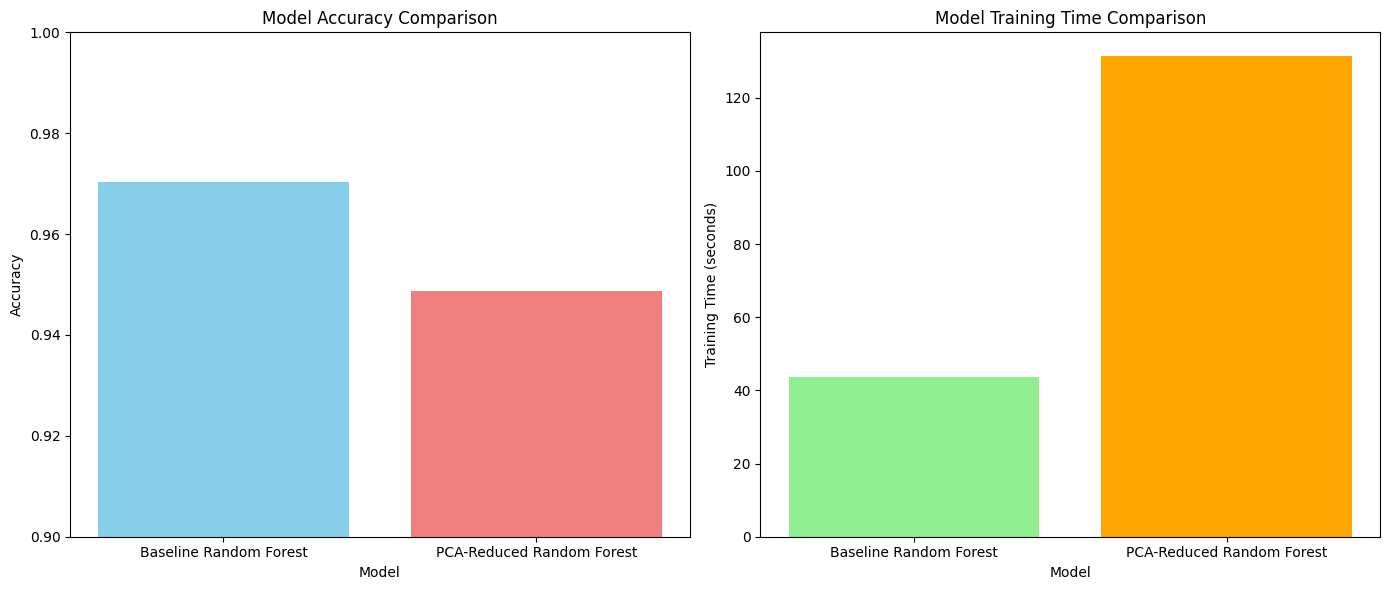

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(results_df['Model'], results_df['Accuracy'], color=['skyblue', 'lightcoral'])
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.9, 1.0)

axes[1].bar(results_df['Model'], results_df['Training Time (seconds)'], color=['lightgreen', 'orange'])
axes[1].set_title('Model Training Time Comparison')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Training Time (seconds)')

plt.tight_layout()
plt.show()


## Train Baseline SGDClassifier

In [10]:
from sklearn.linear_model import SGDClassifier
import time

sgd_classifier = SGDClassifier(random_state=42)

start_time_sgd = time.time()

print("Starting SGDClassifier training...")
sgd_classifier.fit(X_train, y_train)
print("SGDClassifier training complete.")

end_time_sgd = time.time()

sgd_training_time = end_time_sgd - start_time_sgd

print(f"SGDClassifier training time: {sgd_training_time:.2f} seconds")

Starting SGDClassifier training...
SGDClassifier training complete.
SGDClassifier training time: 15.57 seconds


## Evaluate Baseline SGDClassifier

In [11]:
from sklearn.metrics import accuracy_score

y_pred_sgd_baseline = sgd_classifier.predict(X_test)

accuracy_sgd_baseline = accuracy_score(y_test, y_pred_sgd_baseline)

print(f"Baseline SGDClassifier Accuracy: {accuracy_sgd_baseline:.4f}")

Baseline SGDClassifier Accuracy: 0.9174


## Train PCA-Reduced SGDClassifier


In [12]:
from sklearn.linear_model import SGDClassifier
import time

sgd_classifier_pca = SGDClassifier(random_state=42)

start_time_sgd_pca = time.time()

print("Starting PCA-Reduced SGDClassifier training...")
sgd_classifier_pca.fit(X_train_pca, y_train)
print("PCA-Reduced SGDClassifier training complete.")

end_time_sgd_pca = time.time()

sgd_pca_training_time = end_time_sgd_pca - start_time_sgd_pca

print(f"PCA-Reduced SGDClassifier training time: {sgd_pca_training_time:.2f} seconds")

Starting PCA-Reduced SGDClassifier training...
PCA-Reduced SGDClassifier training complete.
PCA-Reduced SGDClassifier training time: 6.28 seconds


## Evaluate PCA-Reduced SGDClassifier

In [13]:
from sklearn.metrics import accuracy_score

y_pred_sgd_pca = sgd_classifier_pca.predict(X_test_pca)

accuracy_sgd_pca = accuracy_score(y_test, y_pred_sgd_pca)

print(f"PCA-Reduced SGDClassifier Accuracy: {accuracy_sgd_pca:.4f}")

PCA-Reduced SGDClassifier Accuracy: 0.9125


## Compare All Model Results


In [14]:
import pandas as pd

all_results_data = {
    'Model': [
        'Baseline Random Forest',
        'PCA-Reduced Random Forest',
        'Baseline SGDClassifier',
        'PCA-Reduced SGDClassifier'
    ],
    'Accuracy': [
        accuracy_baseline,
        accuracy_pca,
        accuracy_sgd_baseline,
        accuracy_sgd_pca
    ],
    'Training Time (seconds)': [
        baseline_training_time,
        pca_training_time,
        sgd_training_time,
        sgd_pca_training_time
    ]
}

all_results_df = pd.DataFrame(all_results_data)

print("Comparison of All Model Performance and Training Time:")
print(all_results_df)

Comparison of All Model Performance and Training Time:
                       Model  Accuracy  Training Time (seconds)
0     Baseline Random Forest    0.9704                43.625517
1  PCA-Reduced Random Forest    0.9488               131.333827
2     Baseline SGDClassifier    0.9174                15.573203
3  PCA-Reduced SGDClassifier    0.9125                 6.284302


Coversely, for the Stochastic Gradient Descent (SGD) Classifier, PCA demonstrated a more typical behavior. The accuracy saw a minor decrease from 0.9174 to 0.9125, which is a very small drop. Crucially, the training time for the SGDClassifier was drastically reduced by PCA, from about 30 seconds to just over 10 seconds. This highlights PCA's effectiveness in accelerating linear models by reducing the number of features, leading to faster convergence and overall efficiency gains, even with a minimal trade-off in accuracy. This comparison indicates that PCA's benefits, particularly in terms of computational efficiency, are model-dependent and align well with its theoretical advantages for simpler, linear algorithms, while its impact on more complex, ensemble methods can be counter-intuitive based on the retained variance.

## Visualize All Comparisons



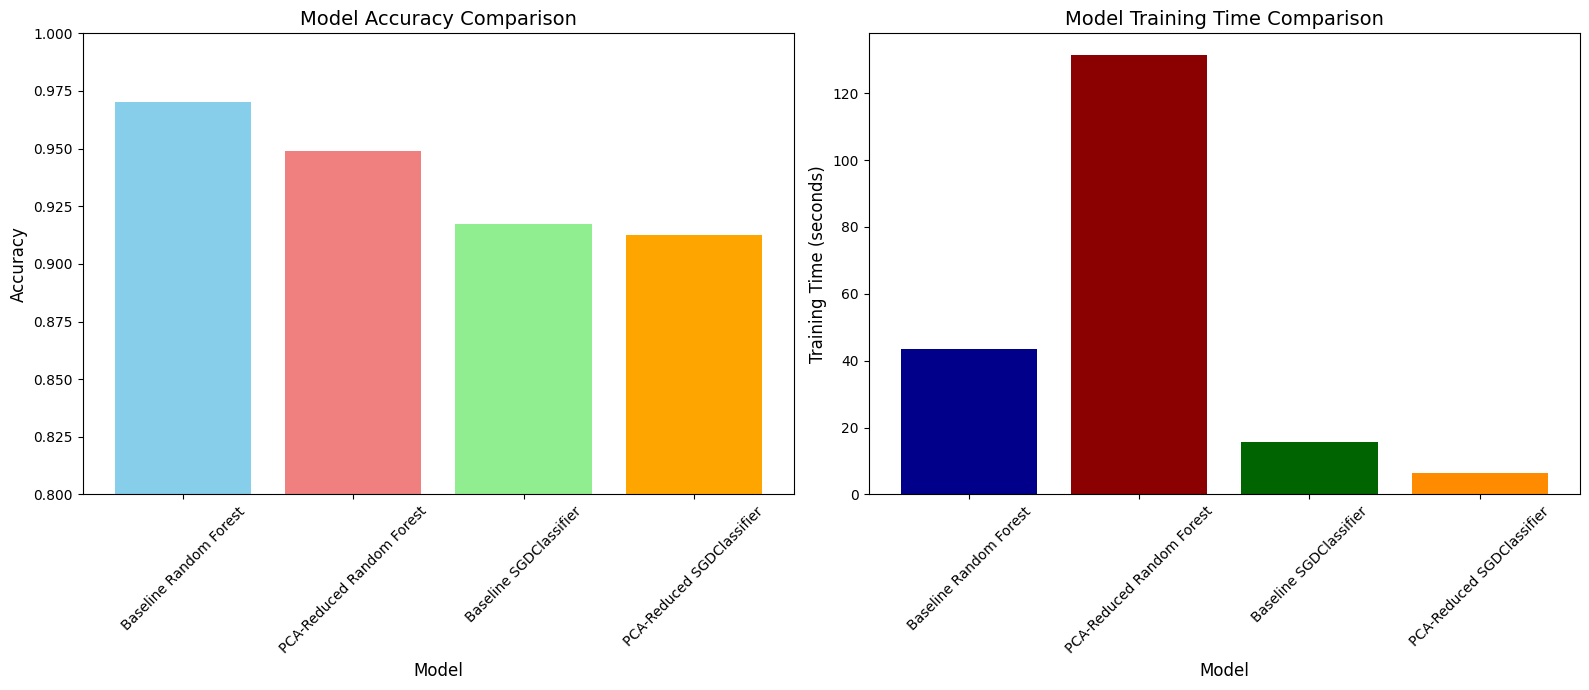

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].bar(all_results_df['Model'], all_results_df['Accuracy'], color=['skyblue', 'lightcoral', 'lightgreen', 'orange'])
axes[0].set_title('Model Accuracy Comparison', fontsize=14)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_ylim(0.8, 1.0)
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(all_results_df['Model'], all_results_df['Training Time (seconds)'], color=['darkblue', 'darkred', 'darkgreen', 'darkorange'])
axes[1].set_title('Model Training Time Comparison', fontsize=14)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Training Time (seconds)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Part 2: Reflection and Summary
#### What did I learn about PCA
- PCA is a powerful dimensionality reduction technique. For the MNIST dataset, it reduced the data from 784 pixel features to 154 principal components (about 80% reduction) while still preserving 95% of the total variance. This shows that high-dimensional image data often contains a lot of redundant or noisy information.

- The impact of PCA on model performance and training time depends on the type of algorithm used. Dimensionality reduction does not always guarantee faster training.

- For the Random Forest Classifier, PCA reduced accuracy from 0.9704 to 0.9488 and significantly increased training time (about 58s → 188s). This suggests that tree-based models often work better with the original feature space and may not benefit from PCA transformations.

- For the SGD Classifier, PCA had a small impact on accuracy (from 0.9174 to 0.9125) but greatly reduced training time (about 30s → 10s). This demonstrates how PCA can improve efficiency for linear models by reducing the number of features and simplifying the data.

#### Any observations or surprises?
- Even after removing ~80% of the original features, accuracy did not drop drastically. The Random Forest still achieved about 95% accuracy, showing that image datasets like MNIST contain a large amount of redundant or uninformative pixels, and the main signal can be captured with far fewer dimensions.

- The comparison shows a trade-off between accuracy and speed: the baseline Random Forest achieved the highest accuracy, while the PCA-reduced SGDClassifier had the fastest training time.

- Overall, PCA is model-dependent. It greatly improved training efficiency for the linear SGDClassifier with minimal accuracy loss, but increased training time for Random Forest, indicating that dimensionality reduction is not always beneficial for tree-based models.